# Project 29 — Game-State Reconstruction (Colab)

Reconstructs the state of the card game **29** from overhead-ish gameplay video:
per trick, map *player → card*, track trump and marriage, then score the hand.

**Pipeline**

1. **Table registration** — the footage is hand-held and drifts, so every frame is
   fitted to the table's ellipse and warped onto a canonical top-down disc.
   Everything downstream lives in that stable frame of reference.
2. **Region semantics** — a card's *role* is positional. Table centre = a played
   trick card; the trump spot = the trump indicator (only its **suit** matters, the
   rank is deliberately off-deck); the counter spot = one of the four 6s used for
   scorekeeping; the top edge = face-down hands.
3. **Detection + classification** — YOLO26 over the 32-card closed set, trained on
   scenes composited in canonical space over real table backgrounds.
4. **Seat assignment** — the four played cards land in a cross. Seats come from each
   card's *bearing from that trick's centroid*, so it survives table wander.
5. **Rules engine** — trick winners, marriage, and bid resolution.

> **Read this before trusting the numbers.** No real card scans exist yet, so the
> deck is rendered procedurally. Detection (*where* cards are) will transfer to real
> footage; classification (*which* card) largely will not, because the synthetic faces
> don't look like the real deck. Scan the 32 cards into `data/reference/<CODE>.png`
> to close that gap. Section 9 measures the difference rather than assuming it.

## 0. Configuration — the only cell you need to edit

## 1. Runtime check

In [1]:
!pip install torch
!pip install -q "ultralytics==8.4.107" 2>&1 | tail -2
%pip install --upgrade --force-reinstall "numpy<2" matplotlib
!pip install p29
%pip install --force-reinstall --no-cache-dir "numpy==1.26.4" "pandas<3" scipy matplotlib opencv-python

Defaulting to user installation because normal site-packages is not writeable


'tail' is not recognized as an internal or external command,
operable program or batch file.


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.3 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.3.0 which is incompatible.


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ------ --------------------------------- 2.4/15.5 MB 12.2 MB/s eta 0:00:02
   ---------- ----------------------------- 4.2/15.5 MB 10.1 MB/s eta 0:00:02
   ------------- -------------------------- 5.2/15.5 MB 8.4 MB/s eta 0:00:02
   ---------------- ----------------------- 6.6/15.5 MB 8.0 MB/s eta 0:00:02
   -------------------- --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.3 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.3.0 which is incompatible.


In [2]:
import torch, ultralytics
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
print("ultralytics", ultralytics.__version__)
assert torch.cuda.is_available(), "no GPU - Runtime > Change runtime type > GPU"

torch 2.7.1+cu118 | cuda True
ultralytics 8.4.139


## 2. Project tree

In [3]:
# --- data -------------------------------------------------------------------
# Leave DRIVE_VIDEO_DIR empty to search your Drive for the videos by name -- a
# share link gives a folder id, not a path, so the path cannot be derived from it.
# Set it explicitly only if the search picks the wrong copy.
DRIVE_VIDEO_DIR = ""
VIDEO_GLOB = "29-gameplay-*.mp4"
USE_DRIVE = True          # False -> browser upload widget instead

# --- training ---------------------------------------------------------------
N_TRAIN, N_VAL = 4000, 600   # synthetic scenes
EPOCHS = 60
BATCH = 32                   # drop to 16 if the T4 runs out of memory
IMGSZ = 512                  # must stay equal to CANON_SIZE

# --- reconstruction ---------------------------------------------------------
SAMPLE_FPS = 4.0          # how often to look at the video
CONF = 0.30               # detector threshold; voting tolerates a permissive value

# --- rules ------------------------------------------------------------------
# Who led the very first trick. The video cannot tell you this; in 29 it is the
# bid winner. Every later leader is derived (winner of a trick leads the next).
FIRST_LEADER = 1
DEFAULT_TRUMP_CODE = "S"  # S/H/D/C. Trump is not read off the table yet.
BID_TEAM, BID = "A", 16   # team A = players 1 & 3, team B = 2 & 4

### generate all the markdown files for rules and games

In [4]:
import nbformat
from nbclient import NotebookClient

nb = nbformat.read("Z:\\coding\\PR project\\file-generation.ipynb", as_version=4)
client = NotebookClient(nb, timeout=600, kernel_name="python3")
client.execute()

c:\ProgramData\anaconda3\Lib\site-packages\zmq\_future.py:693: RuntimeWarning: Proactor event loop does not implement add_reader family of methods required for zmq. Registering an additional selector thread for add_reader support via tornado. Use `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())` to avoid this warning.
  self._get_loop()


{'cells': [{'cell_type': 'markdown',
   'id': 'c712ef9e',
   'metadata': {},
   'source': '## 3. Generate files first \n\ncard_faces, cards, regions, registration, rules, scoring, synthetic_cannon, tracking - these .py files need to be generated first for running the other cells. If they are present already, nothing needs to be done\n\nCopied verbatim from the repo (unit-tested there); regenerate with `tools/build_colab_notebook.py`.\n'},
  {'cell_type': 'markdown',
   'id': '293826fb',
   'metadata': {},
   'source': '### Procedural deck and the canonical-space scene compositor'},
  {'cell_type': 'code',
   'execution_count': 1,
   'id': 'e4faab47',
   'metadata': {'execution': {'iopub.status.busy': '2026-09-17T17:24:22.171577Z',
     'iopub.execute_input': '2026-09-17T17:24:22.172424Z',
     'shell.execute_reply': '2026-09-17T17:24:22.179423Z',
     'iopub.status.idle': '2026-09-17T17:24:22.180438Z'}},
   'outputs': [{'output_type': 'stream',
     'name': 'stdout',
     'text': 'Over

In [5]:
import os
for d in ["p29", "p29/engine", "p29/vision", "p29/datagen",
          "data/raw", "data/reference", "dataset"]:
    os.makedirs(d, exist_ok=True)
for pkg in ["p29", "p29/engine", "p29/vision", "p29/datagen"]:
    open(os.path.join(pkg, "__init__.py"), "w").close()
print("tree ready")

tree ready


In [6]:
VIDEO1_PATH="Z:\\coding\\PR project\\29-card-game\\29-gameplay-1 - Converted.mp4"
VIDEO2_PATH="Z:\\coding\\PR project\\29-card-game\\29-gameplay-2.mp4"
TRIMMED_PATH="Z:\\coding\\PR project\\29-card-game\\trimmed.mp4"

## 4. Upload the gameplay videos

Upload `29-gameplay-1.mp4` and `29-gameplay-2.mp4` into `data/raw/`. Mounting Drive
is far faster than the upload widget for files this size (78 MB and 184 MB).

In [7]:
# import glob, shutil
# import os
# if USE_DRIVE:
#     from google.colab import drive
#     drive.mount("/content/drive")

#     source_dir = DRIVE_VIDEO_DIR
#     if not source_dir:
#         # A Drive share link carries a folder id, not a path, so locate the videos
#         # by filename instead of guessing where in the Drive they were put.
#         hits = glob.glob(f"/content/drive/MyDrive/**/{VIDEO_GLOB}", recursive=True)
#         assert hits, (f"no {VIDEO_GLOB} found under /content/drive/MyDrive - "
#                       "set DRIVE_VIDEO_DIR manually")
#         source_dir = os.path.dirname(sorted(hits)[0])
#         print("found videos in:", source_dir)

#     for src in sorted(glob.glob(os.path.join(source_dir, "*.mp4"))):
#         dst = os.path.join("/", os.path.basename(src))
#         if not os.path.exists(dst):
#             shutil.copy(src, dst)
#     # Real card scans, if you have made them, live alongside the videos.
#     for src in glob.glob(os.path.join(source_dir, "reference", "*.png")):
#         shutil.copy(src, os.path.join("data/reference", os.path.basename(src)))
# else:
#     from google.colab import files
#     for name in files.upload():
#         os.rename(name, f"29-card-game/{name}")

# VIDEOS = sorted(glob.glob("29-card-game/*.mp4"))
# scans = glob.glob("data/reference/*.png")
# print("videos:", [os.path.basename(v) for v in VIDEOS])
# print(f"card scans: {len(scans)}/32" + ("" if scans else "  (procedural deck will be used)"))
# assert VIDEOS, "no videos copied - check DRIVE_VIDEO_DIR"

In [8]:
from pathlib import Path
import shutil
import os

# Set this to the local folder containing the gameplay videos.
LOCAL_VIDEO_DIR = Path(r"Z:\coding\PR project")
LOCAL_VIDEO_GLOB = "29-gameplay-*.mp4"

assert LOCAL_VIDEO_DIR.is_dir(), f"local video folder does not exist: {LOCAL_VIDEO_DIR}"
os.makedirs("29-card-game", exist_ok=True)
os.makedirs("data/reference", exist_ok=True)

# Copy videos into the location used by the rest of the notebook.
for src in sorted(LOCAL_VIDEO_DIR.glob(LOCAL_VIDEO_GLOB)):
    shutil.copy2(src, Path("29-card-game") / src.name)

# Optional real card scans: JS.png, 10H.png, 7C.png, ...
local_reference_dir = LOCAL_VIDEO_DIR / "reference"
if local_reference_dir.is_dir():
    for src in sorted(local_reference_dir.glob("*.png")):
        shutil.copy2(src, Path("data/reference") / src.name)

VIDEOS = sorted(str(path) for path in Path("29-card-game").glob("*.mp4"))
scans = sorted(Path("data/reference").glob("*.png"))
print("videos:", [Path(video).name for video in VIDEOS])
print(f"card scans: {len(scans)}/32" + ("" if scans else "  (procedural deck will be used)"))
assert VIDEOS, f"no {LOCAL_VIDEO_GLOB} files found in {LOCAL_VIDEO_DIR}"

videos: ['29-gameplay-1 - Converted.mp4', '29-gameplay-1.mp4', '29-gameplay-2.mp4', 'trimmed.mp4']
card scans: 0/32  (procedural deck will be used)


## 5. Registration sanity check

If this looks wrong, nothing downstream can be right.

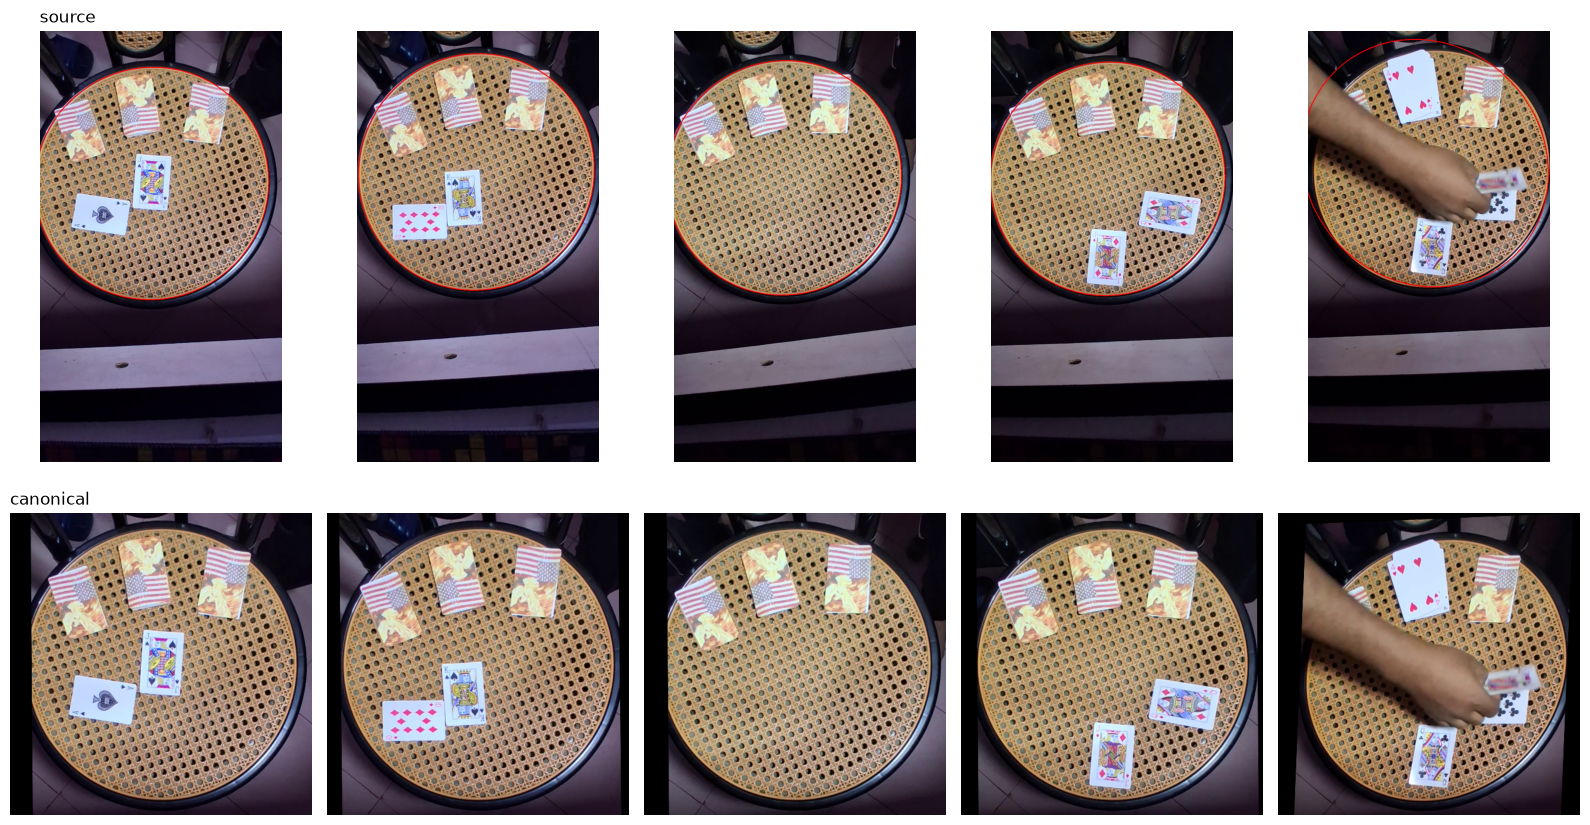

table fitted on 5/5 sampled frames


In [9]:
import cv2, numpy as np, matplotlib.pyplot as plt
from p29.vision.registration import fit_table, TableTracker, CANON_SIZE, CANON_RADIUS

cap = cv2.VideoCapture(VIDEOS[0])
n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fig, axes = plt.subplots(2, 5, figsize=(16, 9))
ok_count = 0
for col, idx in enumerate(np.linspace(n * .05, n * .95, 5).astype(int)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ok, frame = cap.read()
    if not ok:
        continue
    fit = fit_table(frame)
    shown = frame.copy()
    if fit:
        ok_count += 1
        cv2.ellipse(shown, ((fit.cx, fit.cy), (fit.major, fit.minor), fit.angle), (0, 0, 255), 2)
        warped = fit.warp(frame)
    else:
        warped = np.zeros((CANON_SIZE, CANON_SIZE, 3), np.uint8)
    axes[0, col].imshow(cv2.cvtColor(shown, cv2.COLOR_BGR2RGB)); axes[0, col].axis("off")
    axes[1, col].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)); axes[1, col].axis("off")
axes[0, 0].set_title("source", loc="left"); axes[1, 0].set_title("canonical", loc="left")
cap.release()
plt.tight_layout(); plt.show()
print(f"table fitted on {ok_count}/5 sampled frames")

## 6. Build the synthetic dataset

Real table backgrounds, procedural cards, composited in canonical space.

In [10]:
import random, shutil
from card_faces import load_gallery
from synthetic_canon import make_scene, harvest_backgrounds
from p29.vision.registration import TableTracker

GALLERY = load_gallery("data/reference")  # real scans win when present
BACKGROUNDS = harvest_backgrounds(VIDEOS, TableTracker, max_per_video=60)

print(BACKGROUNDS)
print("empty-table backgrounds harvested:", len(BACKGROUNDS))
assert BACKGROUNDS, "no clean backgrounds found - check registration above"

gallery: 32 cards (0 real scans, 32 procedural)
[array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       ...,

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [35, 20, 34],
        [35, 20, 34],
        [35, 20, 34]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [35, 20, 34],
        [35, 20, 34],
        [35, 20, 34]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [35, 20, 34],
        [35, 20, 34],
        [35, 20, 34]]], dtype=uint8), array([[[0, 0, 0],
        [0, 0, 0],
    

In [11]:
import random
import cv2

In [12]:
CLASS_NAMES = [f"{r}{s}" for s in ["S", "H", "D", "C"]
               for r in ["7", "8", "9", "10", "J", "Q", "K", "A"]]
CLASS_INDEX = {c: i for i, c in enumerate(CLASS_NAMES)}
print(CLASS_INDEX)
assert len(CLASS_NAMES) == 32

def build_split(split, count, seed):
    rng = random.Random(seed)
    img_dir, lbl_dir = f"dataset/images/{split}", f"dataset/labels/{split}"
    shutil.rmtree(img_dir, ignore_errors=True); shutil.rmtree(lbl_dir, ignore_errors=True)
    os.makedirs(img_dir, exist_ok=True); os.makedirs(lbl_dir, exist_ok=True)
    for i in range(count):
        scene, anns = make_scene(GALLERY, BACKGROUNDS, rng)
        cv2.imwrite(f"{img_dir}/{i:06d}.jpg", scene)
        with open(f"{lbl_dir}/{i:06d}.txt", "w") as fh:
            for codeval, (x1, y1, x2, y2) in anns:
                cx = (x1 + x2) / 2 / CANON_SIZE; cy = (y1 + y2) / 2 / CANON_SIZE
                w = (x2 - x1) / CANON_SIZE;      h = (y2 - y1) / CANON_SIZE
                fh.write(f"{CLASS_INDEX[codeval]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
    print(f"{split}: {count} scenes")

build_split("train", N_TRAIN, seed=0)
build_split("val",   N_VAL,   seed=1)

with open("dataset/dataset.yaml", "w") as fh:
    fh.write("path: /content/dataset\ntrain: images/train\nval: images/val\n")
    fh.write(f"nc: 32\nnames: {CLASS_NAMES}\n")
print(open("dataset/dataset.yaml").read())

{'7S': 0, '8S': 1, '9S': 2, '10S': 3, 'JS': 4, 'QS': 5, 'KS': 6, 'AS': 7, '7H': 8, '8H': 9, '9H': 10, '10H': 11, 'JH': 12, 'QH': 13, 'KH': 14, 'AH': 15, '7D': 16, '8D': 17, '9D': 18, '10D': 19, 'JD': 20, 'QD': 21, 'KD': 22, 'AD': 23, '7C': 24, '8C': 25, '9C': 26, '10C': 27, 'JC': 28, 'QC': 29, 'KC': 30, 'AC': 31}
train: 4000 scenes
val: 600 scenes
path: /content/dataset
train: images/train
val: images/val
nc: 32
names: ['7S', '8S', '9S', '10S', 'JS', 'QS', 'KS', 'AS', '7H', '8H', '9H', '10H', 'JH', 'QH', 'KH', 'AH', '7D', '8D', '9D', '10D', 'JD', 'QD', 'KD', 'AD', '7C', '8C', '9C', '10C', 'JC', 'QC', 'KC', 'AC']



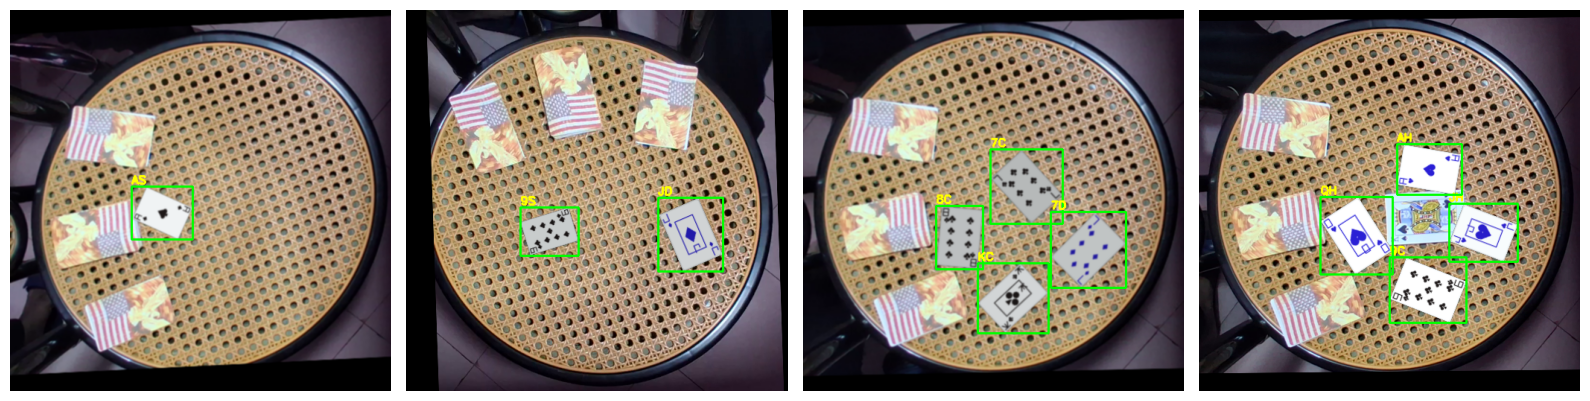

In [13]:
# Eyeball a few training samples with their boxes -- label bugs are invisible in mAP.
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
rng = random.Random(7)
for ax in axes:
    scene, anns = make_scene(GALLERY, BACKGROUNDS, rng)
    shown = scene.copy()
    for codeval, (x1, y1, x2, y2) in anns:
        cv2.rectangle(shown, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(shown, codeval, (x1, max(12, y1 - 4)), 0, 0.5, (0, 255, 255), 2)
    ax.imshow(cv2.cvtColor(shown, cv2.COLOR_BGR2RGB)); ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Train

YOLO26 ships inside `ultralytics` 8.4.x. The checkpoint name has changed across
releases, so this tries the current one and falls back rather than dying on a 404 —
whatever it lands on is printed, so the result is never ambiguous.

In [14]:
# from ultralytics import YOLO

# MODEL = None
# for candidate in ["yolo26s.pt", "yolo26n.pt", "yolo11s.pt", "yolov8s.pt"]:
#     try:
#         MODEL = YOLO(candidate)
#         print("using:", candidate)
#         break
#     except Exception as exc:
#         print(f"  {candidate} unavailable ({type(exc).__name__})")
# assert MODEL is not None, "no usable checkpoint"

In [15]:
# MODEL.train(
#     data="Z:\coding\PR project\dataset\dataset.yaml",
#     epochs=EPOCHS,
#     imgsz=IMGSZ,        # matches CANON_SIZE, so no rescaling
#     batch=BATCH,
#     device=0,
#     workers=2,
#     patience=15,
#     project="runs", name="p29",
#     exist_ok=True,
#     # Geometry is already normalised by registration, so keep spatial aug mild
#     # and let colour/lighting aug do the work.
#     degrees=180.0, translate=0.08, scale=0.25, fliplr=0.0, mosaic=0.5,
#     hsv_h=0.02, hsv_s=0.6, hsv_v=0.5,
# )
# print("best weights:", MODEL.trainer.best)

In [16]:
from ultralytics import YOLO

# MODEL_PATH = "Z:\\coding\\PR project\\card-detection\\runs\\detect\\train13\\weights\\best.pt"
MODEL_PATH = "Z:\coding\PR project\card-detection\yolov8n.pt"
MODEL = YOLO(MODEL_PATH)

print(MODEL)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
C:\Users\nnahe\AppData\Local\Temp\ipykernel_33176\3574655620.py:4: SyntaxWarning: invalid escape sequence '\c'
  MODEL_PATH = "Z:\coding\PR project\card-detection\yolov8n.pt"


## 8. Detector check on a real frame

Defines the one detection helper the rest of the notebook uses, and shows it working
on a real frame. Worth a look before the full run: a detector that finds nothing here
will produce an empty table in section 9 and no explanation of why.

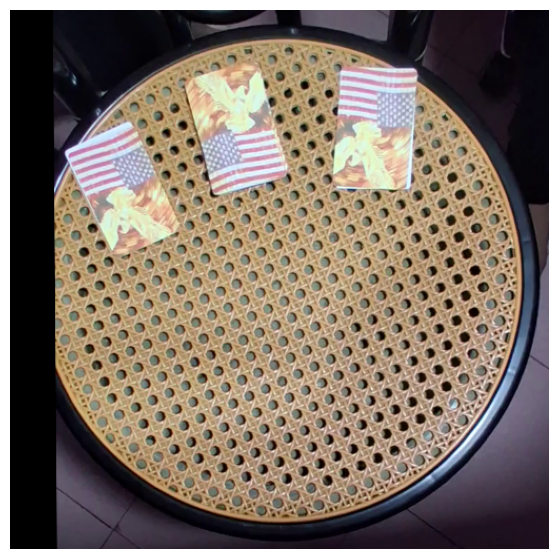

0 card(s) detected, 0 in the trick area


In [17]:
from p29.vision.regions import TableLayout, Role, assign_seats

best = YOLO(MODEL)
LAYOUT = TableLayout()

def detect_cards(warped, conf=CONF):
    """Detect cards in a canonical-space frame and tag each with its table role."""
    det = best.predict(warped, conf=conf, verbose=False)[0]
    items = []
    for box, cls, cf in zip(det.boxes.xyxy.cpu().numpy(),
                            det.boxes.cls.cpu().numpy().astype(int),
                            det.boxes.conf.cpu().numpy()):
        cx, cy = float((box[0] + box[2]) / 2), float((box[1] + box[3]) / 2)
        items.append({"code": CLASS_NAMES[cls], "conf": float(cf), "xy": (cx, cy),
                      "box": box, "role": LAYOUT.classify(cx, cy)})
    return items

# One real frame, overlaid.
cap = cv2.VideoCapture(VIDEOS[0])
cap.set(cv2.CAP_PROP_POS_FRAMES, int(200 * cap.get(cv2.CAP_PROP_FPS)))
ok, frame = cap.read(); cap.release()
fit = fit_table(frame) if ok else None

if fit is None:
    print("registration failed on this frame")
else:
    warped = fit.warp(frame)
    items = detect_cards(warped)
    trick = [i for i in items if i["role"] is Role.TRICK]
    if trick:
        for item, seat in zip(trick, assign_seats(np.array([i["xy"] for i in trick]))):
            item["seat"] = seat

    shown = warped.copy()
    for i in items:
        x1, y1, x2, y2 = i["box"].astype(int)
        cv2.rectangle(shown, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(shown, f"{i['code']} {i.get('seat', i['role'].value)}",
                    (x1, max(12, y1 - 5)), 0, 0.45, (0, 255, 255), 1)
    plt.figure(figsize=(7, 7)); plt.imshow(cv2.cvtColor(shown, cv2.COLOR_BGR2RGB))
    plt.axis("off"); plt.show()
    print(f"{len(items)} card(s) detected, {len(trick)} in the trick area")

In [18]:
fit
items = detect_cards(warped)

print(items)

[]


## 9. Full pipeline — every game, every trick, every player

**This is the deliverable.** Both videos are processed end to end and the result is,
per game and per trick, which card each player played.

Three things happen here that single-frame analysis cannot do:

* **Trick segmentation** — cards pile up in the play area and are swept away when the
  trick is taken. That sweep is the boundary between tricks.
* **Voting** — a card sits on the table for many frames and so is classified many
  times. The consensus is much stronger than any single frame, which matters a lot at
  ~55x85 px per card.
* **Uniqueness** — each of the 32 cards is played exactly once per game, so the whole
  game is solved as one assignment problem instead of 32 independent guesses. If two
  slots both want `9H`, only the stronger keeps it and the other is pushed to its best
  remaining option. This is the main error-corrector.

In [19]:
from tracking import (
    Detection, TrickSegmenter, split_games, enforce_uniqueness,
    to_player_mapping, SEAT_TO_PLAYER,
)

def process_video(video_path, sample_fps=SAMPLE_FPS, conf=CONF, verbose=True):
    """Run detection + segmentation over a whole video. Returns raw tricks."""
    cap = cv2.VideoCapture(video_path)
    fps = max(cap.get(cv2.CAP_PROP_FPS), 1.0)
    step = max(1, int(round(fps / sample_fps)))

    tracker = TableTracker()
    # These two guards are what stop detector flicker from shredding one trick into
    # many. Measured on the real footage with a classical blob detector, a naive
    # emptiness test fired ~89 times on a video containing 8 tricks -- so a trick
    # must also survive a minimum duration. Tune both with the section 9 checks.
    segmenter = TrickSegmenter(
        min_empty_frames=int(sample_fps * 1.5),
        min_peak_cards=2,
        min_trick_frames=int(fps * 2.0),
    )
    seen = fitted = 0

    # Decode sequentially and skip with grab(); seeking to each sampled frame
    # measured ~20x slower on this footage, and lands on keyframes rather than the
    # frame asked for.
    idx = -1
    while True:
        if not cap.grab():
            break
        idx += 1
        if idx % step:
            continue
        ok, frame = cap.retrieve()
        if not ok:
            break
        seen += 1
        fit = tracker.update(frame)
        if fit is None:
            continue
        fitted += 1

        found = [
            Detection(i["code"], i["conf"], *i["xy"])
            for i in detect_cards(fit.warp(frame), conf=conf)
            if i["role"] is Role.TRICK
        ]
        segmenter.feed(idx, found)

    cap.release()
    tricks = segmenter.finish()
    if verbose:
        print(f"{os.path.basename(video_path)}: {seen} frames sampled, "
              f"{fitted} registered, {len(tricks)} tricks segmented")
    return tricks, fps

ImportError: attempted relative import with no known parent package

In [ ]:
def reconstruct(video_path):
    """Full reconstruction for one video -> list of games, each a list of tricks."""
    tricks, fps = process_video(video_path)
    # A deal takes far longer than the gap between tricks in a game.
    games = split_games(tricks, tricks_per_game=8, deal_gap_frames=int(fps * 25))

    out = []
    for g_idx, game_tricks in enumerate(games):
        resolved = enforce_uniqueness(game_tricks, CLASS_NAMES)
        rows = []
        for t_idx, (raw, seat_map) in enumerate(zip(game_tricks, resolved)):
            rows.append({
                "trick": t_idx,
                "start_s": round(raw.start_frame / fps, 1),
                "cards_seen": raw.peak_cards,
                "players": to_player_mapping(seat_map),
            })
        out.append({"game": g_idx, "tricks": rows})
    return out

ALL_GAMES = {}
for path in VIDEOS:
    ALL_GAMES[os.path.basename(path)] = reconstruct(path)
print("\ndone")

29-gameplay-1.mp4: 1548 frames sampled, 1548 registered, 0 tricks segmented
29-gameplay-2.mp4: 5132 frames sampled, 5132 registered, 0 tricks segmented

done


### The answer — cards played, per game and per trick

In [ ]:
import json
import pandas as pd

records, PLAY_ARRAY = [], {}
for video, games in ALL_GAMES.items():
    PLAY_ARRAY[video] = []
    for game in games:
        PLAY_ARRAY[video].append(
            [[t["players"].get(p) for p in (1, 2, 3, 4)] for t in game["tricks"]])
        for trick in game["tricks"]:
            row = {"video": video, "game": game["game"], "trick": trick["trick"],
                   "t(s)": trick["start_s"], "seen": trick["cards_seen"]}
            for player in (1, 2, 3, 4):
                row[f"P{player}"] = trick["players"].get(player, "-")
            records.append(row)

TABLE = pd.DataFrame(records)
pd.set_option("display.width", 140)
print(TABLE.to_string(index=False) if len(TABLE) else "no tricks reconstructed")

print("\n[game][trick] -> [P1, P2, P3, P4]")
print(json.dumps(PLAY_ARRAY, indent=1))

with open("reconstruction.json", "w") as fh:
    json.dump(PLAY_ARRAY, fh, indent=1)
TABLE.to_csv("reconstruction.csv", index=False)
print("\nsaved reconstruction.json / reconstruction.csv")

no tricks reconstructed

[game][trick] -> [P1, P2, P3, P4]
{
 "29-gameplay-1.mp4": [],
 "29-gameplay-2.mp4": []
}

saved reconstruction.json / reconstruction.csv


### Read the diagnostics before trusting the table

`seen` is how many cards were visible at the trick's fullest. **A trick showing fewer
than 4 was never fully observed**, so its missing seats are gaps, not errors — usually a
hand covering the table at the wrong moment.

Two sanity checks worth doing on the output above:

* **8 tricks per game.** More means one trick got split by a dropout; fewer means two
  merged, or the sweep was missed. Adjust `min_empty_frames` in `process_video`.
* **3 games total** across the two videos (1 + 2). If `split_games` disagrees, tune
  `deal_gap_frames` — it is what separates a deal from an ordinary between-trick pause.

In [ ]:
for video, games in ALL_GAMES.items():
    print(f"\n{video}: {len(games)} game(s)")
    for game in games:
        n_tricks = len(game["tricks"])
        full = sum(1 for t in game["tricks"] if t["cards_seen"] == 4)
        named = sum(len(t["players"]) for t in game["tricks"])
        flag = "" if n_tricks == 8 else "   <-- expected 8"
        print(f"  game {game['game']}: {n_tricks} tricks{flag}, "
              f"{full} fully observed, {named}/32 card slots filled")


29-gameplay-1.mp4: 0 game(s)

29-gameplay-2.mp4: 0 game(s)


## 10. Rules engine — trick to score

This part is fully tested and independent of the CV.

In [ ]:
from cards import Card, Suit
from scoring import TrumpInfo, score_hand_from_plays

def score_reconstructed_game(game, trump_suit, first_leader=1, bid_team=None, bid=None):
    """Score a game from section 9, deriving play order from the trick outcomes."""
    plays = []
    for trick in game["tricks"]:
        players = trick["players"]
        if len(players) != 4:
            print(f"  trick {trick['trick']}: incomplete ({sorted(players)}) - skipped")
            continue
        plays.append({p: Card.from_code(c) for p, c in players.items()})
    if not plays:
        return None
    return score_hand_from_plays(
        plays, TrumpInfo(suit=trump_suit, reveal_trick_index=0),
        first_leader=first_leader, bidding_team=bid_team, bid=bid)


# Trump is not read off the table yet (section 11), so supply it per game.
TRUMP_BY_GAME = {}    # e.g. {("29-gameplay-1.mp4", 0): Suit.DIAMONDS}
DEFAULT_TRUMP = Suit(DEFAULT_TRUMP_CODE)

for video, games in ALL_GAMES.items():
    for game in games:
        key = (video, game["game"])
        print(f"\n{video} game {game['game']}:")
        result = score_reconstructed_game(
            game, TRUMP_BY_GAME.get(key, DEFAULT_TRUMP),
            first_leader=FIRST_LEADER, bid_team=BID_TEAM, bid=BID)
        if result is None:
            print("  no complete tricks to score")
            continue
        print("  leaders     :", result.trick_leaders, "(derived)")
        print("  winners     :", result.trick_winners)
        print("  team points :", result.team_points)
        print("  marriage    :", result.marriage_player)
        print("  contract    :", result.contract_made, "->", result.winning_team)

Play order is **derived, not observed**: the winner of a trick leads the next one,
going round the table from there. So the whole sequence follows from one input —
who led the first trick (the bid winner in *29*) — set as `FIRST_LEADER` above.

This is not bookkeeping. The leader fixes the **led suit**, which decides the winner
whenever no trump is played. A wrong leader can flip a winner, which changes the next
leader, so an early mistake propagates through the rest of the hand. If the scores
look wrong, check `FIRST_LEADER` before suspecting the detector.

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "Z:\\coding\\PR project\\card-detection\\pretrained-weights\\yolov8m_synthetic.pt"

model = YOLO(MODEL_PATH)
class_names = model.names
CONF_THRESHOLD = 0.5

results = model.predict(
    source=TRIMMED_PATH,
    conf=CONF_THRESHOLD,
    stream=True,
    verbose=True,
    device=0,
)

detected_cards = set()

for r in results:
    if r.boxes is not None:
        classes = r.boxes.cls.cpu().tolist()
        frame_classes = [class_names[int(c)] for c in classes]
        if frame_classes:
            print(frame_classes)  # per-frame detections, live as it runs
        detected_cards.update(frame_classes)

print(f"\nDetected {len(detected_cards)} unique card class(es) across the video:\n")
for card in sorted(detected_cards):
    print(f"  - {card}")


video 1/1 (frame 1/1508) Z:\coding\PR project\29-card-game\trimmed.mp4: 384x640 (no detections), 90.1ms
video 1/1 (frame 2/1508) Z:\coding\PR project\29-card-game\trimmed.mp4: 384x640 (no detections), 8.8ms
video 1/1 (frame 3/1508) Z:\coding\PR project\29-card-game\trimmed.mp4: 384x640 (no detections), 9.0ms
video 1/1 (frame 4/1508) Z:\coding\PR project\29-card-game\trimmed.mp4: 384x640 (no detections), 8.8ms
video 1/1 (frame 5/1508) Z:\coding\PR project\29-card-game\trimmed.mp4: 384x640 (no detections), 9.2ms
video 1/1 (frame 6/1508) Z:\coding\PR project\29-card-game\trimmed.mp4: 384x640 (no detections), 15.4ms
video 1/1 (frame 7/1508) Z:\coding\PR project\29-card-game\trimmed.mp4: 384x640 (no detections), 9.3ms
video 1/1 (frame 8/1508) Z:\coding\PR project\29-card-game\trimmed.mp4: 384x640 (no detections), 9.5ms
video 1/1 (frame 9/1508) Z:\coding\PR project\29-card-game\trimmed.mp4: 384x640 (no detections), 9.8ms
video 1/1 (frame 10/1508) Z:\coding\PR project\29-card-game\trimmed.mp